# 04 — The Inverse Problem: A Digital Twin that Discovers Hidden Parameters

This is the notebook where PINNs start to *earn their keep*. Everything so far was a **forward** problem: the
physics was fully known, and we computed the solution. But in a real energy plant the situation is usually
reversed:

> *"We have a **few noisy sensors**, we **trust the physics**, but we **don't know a key parameter** —
> the material's thermal diffusivity, the insulation quality, a fouling factor, a leak coefficient.
> Can we estimate it, and reconstruct the full picture the sensors can't see?"*

That is an **inverse problem**, and it is exactly what PINNs are unusually good at. In this notebook we build a
tiny **digital twin** of a heat-conducting component: from a handful of temperature readings we will
**simultaneously**

1. **discover** the unknown thermal diffusivity $\alpha$, and
2. **reconstruct** the entire temperature field $u(x,t)$ — including places and times with *no sensor*.

New idea: a **physical parameter becomes a trainable variable**, learned side-by-side with the network weights.

## 1. Forward vs. inverse — the mental model

```
   FORWARD  (notebook 03)                     INVERSE  (this notebook)
   ─────────────────────                      ───────────────────────
   know:  equation + alpha + IC/BC            know:  equation + a few noisy sensor readings + BC (not IC)
   want:  the field u(x,t)                    want:  the parameter alpha  AND  the field u(x,t)

   physics ──► solver ──► answer              physics + data ──► PINN ──► parameter + field
```

The beautiful part: in a PINN, **the unknown parameter is just another number we optimise**. We add it to the
list of things the optimizer can tune, and the same gradient descent that trains the weights also drives
$\alpha$ toward the value that makes physics and data agree.

## 2. Make synthetic "sensor" data

In a real project the data comes from the field. Here we *fabricate* it from a known true solution so we can
check the answer. We pick a **true** diffusivity $\alpha_\text{true}=0.1$, evaluate the exact heat-equation
solution at a **few sensor positions** and **a few times**, and **add measurement noise**. Then we throw the
true value away and see if the PINN can recover it.

40 noisy sensor readings from 5 locations.


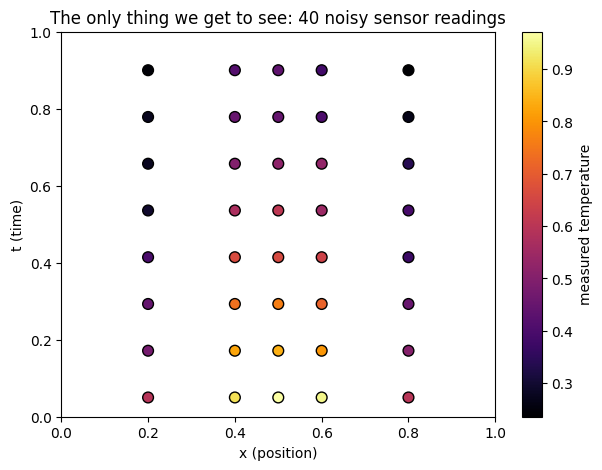

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")

L, T = 1.0, 1.0
alpha_true = 0.10                       # <-- the secret we want to recover
noise_std  = 0.02                       # measurement noise on temperature

def exact(x, t):
    return np.sin(np.pi*x) * np.exp(-alpha_true*np.pi**2*t)

# a realistic, SPARSE sensor layout: 5 positions, 8 time stamps each = 40 readings
sensor_x = np.array([0.2, 0.4, 0.5, 0.6, 0.8])
sensor_t = np.linspace(0.05, 0.9, 8)
Xs, Ts = np.meshgrid(sensor_x, sensor_t)
Xs, Ts = Xs.ravel(), Ts.ravel()
Us = exact(Xs, Ts) + np.random.normal(0, noise_std, size=Xs.shape)   # noisy measurements

print(f"{len(Us)} noisy sensor readings from {len(sensor_x)} locations.")

plt.figure(figsize=(7,5))
sc = plt.scatter(Xs, Ts, c=Us, cmap="inferno", s=60, edgecolor="k")
plt.colorbar(sc, label="measured temperature")
plt.xlabel("x (position)"); plt.ylabel("t (time)")
plt.title("The only thing we get to see: 40 noisy sensor readings"); plt.xlim(0,1); plt.ylim(0,1); plt.show()

## 3. Make the unknown parameter trainable

We store the diffusivity as `log_alpha` and use $\alpha=e^{\log\alpha}$. Two reasons:

- $e^{(\cdot)}$ is always **positive** (a negative diffusivity is unphysical and would blow up),
- it lets $\alpha$ move across orders of magnitude smoothly.

Crucially, `log_alpha` is created with `requires_grad=True` and **handed to the optimizer alongside the network
weights**. We start it at a deliberately **wrong** guess ($\alpha_0=0.4$) to prove the recovery is real.

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden=32, n_hidden_layers=3):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()] # 1st input layer; 2 inputs: x and t
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)] # output layer
        self.net = nn.Sequential(*layers)
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = MLP().to(device) # defined outside a function, so it is a global variable and can be accessed from other functions

alpha0 = 0.40                                              # wrong on purpose (true is 0.10)
# log_alpha is a learnable parameter that represents the logarithm of the thermal diffusivity (alpha) in the PINN model.
# The optimizer will adjust log_alpha to minimize the loss function, and we can recover the actual alpha value by exponentiating log_alpha.
# The key is to use torch.nn.Parameter to make log_alpha a learnable parameter that will be updated during training.
log_alpha = torch.nn.Parameter(torch.tensor(np.log(alpha0), dtype=torch.float32, device=device)) 
# log_alpha is defined outside a function, so it is a global variable and can be accessed from other functions

def get_alpha():
    return torch.exp(log_alpha)

# the optimizer tunes BOTH the network weights AND log_alpha
# in notebook 03: optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
# here we need to include log_alpha in the optimizer so that it can be updated during training along with the model parameters.
optimizer = torch.optim.Adam(list(model.parameters()) + [log_alpha], lr=3e-3)
print("initial alpha guess:", get_alpha().item())

initial alpha guess: 0.3999999761581421


## 4. The loss — physics (with the *current* alpha) + data + known boundaries

$$\mathcal{L}=\underbrace{\overline{(u_t-\alpha\,u_{xx})^2}}_{\text{physics, }\alpha\text{ is being learned}}
\;+\; w_d\underbrace{\overline{(u(x_s,t_s)-u_s^{\text{meas}})^2}}_{\text{match the sensors}}
\;+\; w_b\underbrace{\overline{u(0,t)^2+u(1,t)^2}}_{\text{ends clamped to 0 (known)}}$$

The **data term** is what pins down $\alpha$: only the right diffusivity lets a physics-consistent field also
pass through the measured points. Note there is **no initial-condition term** — we pretend we never measured the
exact starting profile, which is realistic. The physics + sparse data are enough.

meas is an abreviation of measured

In [ ]:
# interior collocation points (physics)
N_f = 1500
x_f = (torch.rand(N_f,1, device=device)*L).requires_grad_(True) # coordinate X
t_f = (torch.rand(N_f,1, device=device)*T).requires_grad_(True) # coordinate T

# boundary points (known: ends at 0)
N_bc = 200
t_bc = torch.rand(N_bc, 1, device=device)*T
x_b0 = torch.zeros(N_bc, 1, device=device); x_bL = torch.ones(N_bc,1, device=device)*L

# sensor tensors
xs = torch.tensor(Xs, dtype=torch.float32, device=device).reshape(-1,1)
tsr = torch.tensor(Ts, dtype=torch.float32, device=device).reshape(-1,1)
us = torch.tensor(Us, dtype=torch.float32, device=device).reshape(-1,1)

# w_data and w_bc are weights for the sensor data and boundary condition loss, respectively.
# these weights are hyperparameters that can be tuned to balance the contributions of each loss term in the total loss function.
# in this case, w_data is set to 50.0 and w_bc is set to 20.0, indicating that the sensor data loss is given more importance than the 
# boundary condition loss in the overall optimization process.
w_data, w_bc = 50.0, 20.0

def pde_residual(x, t):
    a = get_alpha() # alpha now is not a constant, but a learnable parameter that will be updated during training
    u = model(x, t)
    u_t  = torch.autograd.grad(u,  t, torch.ones_like(u),  create_graph=True)[0]
    u_x  = torch.autograd.grad(u,  x, torch.ones_like(u),  create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t - a*u_xx

def compute_loss():
    loss_pde  = torch.mean(pde_residual(x_f, t_f)**2) # physics loss
    loss_data = torch.mean((model(xs, tsr) - us)**2) # sensor data loss
    loss_bc   = torch.mean(model(x_b0, t_bc)**2) + torch.mean(model(x_bL, t_bc)**2) 
    return loss_pde + w_data*loss_data + w_bc*loss_bc, loss_pde, loss_data, loss_bc

## 5. Train — and watch $\alpha$ walk to the truth

We log the estimated $\alpha$ at every step. The headline plot of this notebook is *its trajectory*: starting
from a wrong 0.40 and converging to ~0.10 with **no one ever telling it the answer.**

In [4]:
history, alpha_hist = [], []
for it in range(4001):                    # ~2-3 min on CPU; increase for a touch more accuracy
    optimizer.zero_grad()
    loss, lp, ld, lb = compute_loss()
    loss.backward(); optimizer.step()
    history.append(loss.item()); alpha_hist.append(get_alpha().item())
    if it % 500 == 0:
        print(f"iter {it:5d} | loss {loss.item():.3e} | alpha_est {get_alpha().item():.4f} (true {alpha_true})")

print(f"\nFINAL estimated alpha = {get_alpha().item():.4f}   |   true alpha = {alpha_true}")
print(f"relative error: {abs(get_alpha().item()-alpha_true)/alpha_true*100:.1f}%")

iter     0 | loss 2.446e+01 | alpha_est 0.4012 (true 0.1)
iter   500 | loss 9.412e-02 | alpha_est 0.1705 (true 0.1)
iter  1000 | loss 2.759e-02 | alpha_est 0.1257 (true 0.1)
iter  1500 | loss 2.041e-02 | alpha_est 0.1114 (true 0.1)
iter  2000 | loss 1.924e-02 | alpha_est 0.1061 (true 0.1)
iter  2500 | loss 1.899e-02 | alpha_est 0.1042 (true 0.1)
iter  3000 | loss 1.902e-02 | alpha_est 0.1037 (true 0.1)
iter  3500 | loss 1.881e-02 | alpha_est 0.1036 (true 0.1)
iter  4000 | loss 1.870e-02 | alpha_est 0.1036 (true 0.1)

FINAL estimated alpha = 0.1036   |   true alpha = 0.1
relative error: 3.6%


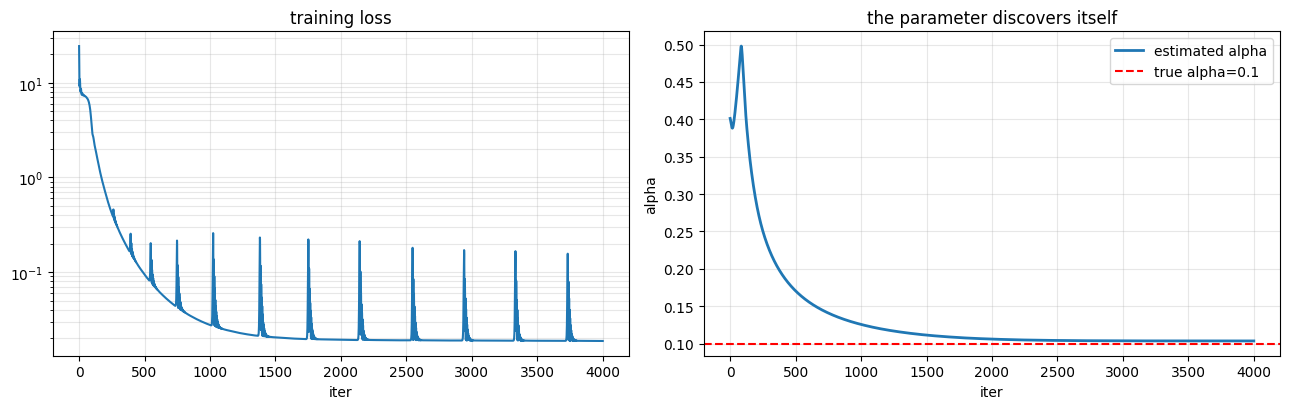

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.2))
ax[0].semilogy(history); ax[0].set_title("training loss"); ax[0].set_xlabel("iter"); ax[0].grid(True, which="both", alpha=0.3)
ax[1].plot(alpha_hist, lw=2, label="estimated alpha")
ax[1].axhline(alpha_true, color="red", ls="--", label=f"true alpha={alpha_true}")
ax[1].set_title("the parameter discovers itself"); ax[1].set_xlabel("iter"); ax[1].set_ylabel("alpha"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Bonus: we also got the full field for free

Recovering $\alpha$ is half the prize. The same trained network is now a **full temperature map** — it fills in
every position and time between the sparse sensors. We compare it to the (secret) exact field to see how well
40 noisy points + physics reconstructed everything.

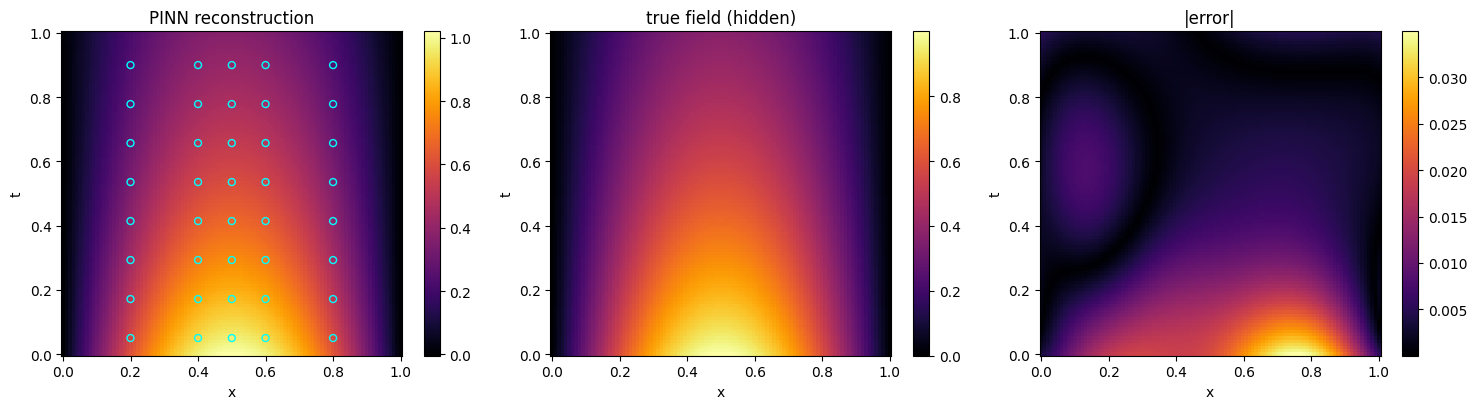

max abs reconstruction error: 0.034962914425023084


In [8]:
nx, nt = 100, 100
xs_g = np.linspace(0,L,nx); ts_g = np.linspace(0,T,nt)
Xg, Tg = np.meshgrid(xs_g, ts_g)
xx = torch.tensor(Xg.ravel(), dtype=torch.float32, device=device).reshape(-1,1)
tt = torch.tensor(Tg.ravel(), dtype=torch.float32, device=device).reshape(-1,1)
with torch.no_grad():
    U_pinn = model(xx, tt).cpu().numpy().reshape(nt, nx)
U_true = np.sin(np.pi*Xg)*np.exp(-alpha_true*np.pi**2*Tg)

fig, axes = plt.subplots(1, 3, figsize=(15,4.2))
for ax, data, title in zip(axes, [U_pinn, U_true, np.abs(U_pinn-U_true)],
                           ["PINN reconstruction", "true field (hidden)", "|error|"]):
    im = ax.pcolormesh(Xg, Tg, data, shading="auto", cmap="inferno")
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title); fig.colorbar(im, ax=ax)
axes[0].scatter(Xs, Ts, s=25, edgecolor="cyan", facecolor="none")  # show sensors on top
plt.tight_layout(); plt.show()
print("max abs reconstruction error:", np.max(np.abs(U_pinn-U_true)))

## 7. Why an energy company cares (the business translation)

Swap the words and this exact pattern becomes a product:

| In this toy notebook | In a real energy asset |
|---|---|
| diffusivity $\alpha$ | insulation quality, fouling factor, soil conductivity, corrosion, leak rate |
| sparse noisy sensors | the handful of real thermocouples / flow meters you actually installed |
| reconstructed field | temperature/pressure everywhere, including where you *can't* put a sensor |
| tracking $\alpha$ over months | **condition monitoring**: a drifting parameter = degradation → predictive maintenance |

Key advantages over pure machine learning here:

- **Physically consistent**: the reconstruction obeys conservation laws, so it extrapolates sanely instead of
  hallucinating.
- **Data-efficient**: 40 noisy points were enough because the physics does the heavy lifting — priceless when
  sensors are expensive.
- **Interpretable**: the recovered $\alpha$ is a real engineering quantity you can trend, alarm on, and explain
  to a regulator.

This "estimate a hidden physical parameter from sparse sensors" pattern is the single most common industrial use
of PINNs.

## 8. Experiments

1. **More noise.** Set `noise_std = 0.05`. How far does the $\alpha$ estimate drift? (Physics regularises, so it
   stays surprisingly good.)
2. **Fewer sensors.** Keep only `sensor_x = [0.3, 0.7]`. At what point does $\alpha$ become unidentifiable?
3. **Different truth.** Set `alpha_true = 0.03` (better insulation). Does it still recover?
4. **Two unknowns.** Advanced: also make a heat-loss coefficient trainable (a taste of notebook 05).

## 9. Recap

- **Inverse problems** — infer hidden parameters and unseen states from sparse data — are the PINN sweet spot.
- A physical parameter is just a **trainable variable**; gradient descent moves it until physics and data agree.
- From 40 noisy points we recovered a material property to a few-percent accuracy **and** reconstructed the full field.
- Business-wise this is **condition monitoring / digital-twin** territory: interpretable, data-efficient, physics-consistent.

**Next (05):** we assemble everything into a realistic energy scenario — a **district-heating pipe** where hot
water flows (advection), diffuses, and loses heat to the ground — and use a PINN to monitor the heat-loss it
can't directly measure.